#EULER PERIODIC ORBIT- SECOND ORDER SYSTEM
## ICs enforced with hard constrains
## Configuration: Bodies 1 & 2 orbit around stationary body 3

## Installation-Imports


*  first set backend
*  install libraries
*  then import modules


In [7]:
import os
os.environ["DDE_BACKEND"] = "tensorflow"

In [8]:
!pip install deepxde matplotlib numpy tensorflow tf_keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 35.2 MB/s eta 0:00:00


In [9]:
import deepxde as dde
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from numpy.linalg import norm

Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


#TRAINING - Adjust weights using PDE Residual Losses
## Now only 6 pde terms. They are all accelaration terms.
## Second order system is better than first order since only 6 pde terms and also more balanced

Set the default float type to float64
Compiling model...
'compile' took 0.005503 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
0         [1.11e+01, 1.40e+00, 8.94e+00, 2.73e+00, 3.51e-01, 1.13e-01]    [1.03e+01, 1.65e+00, 8.03e+00, 2.97e+00, 2.82e-01, 9.59e-02]    []  
1000      [2.97e-01, 1.84e+00, 2.44e-01, 1.75e+00, 6.13e-03, 8.93e-03]    [2.68e-01, 1.81e+00, 2.29e-01, 1.66e+00, 6.90e-03, 6.59e-03]    []  
2000      [6.51e-02, 6.69e-01, 5.16e-02, 6.61e-01, 5.59e-03, 6.78e-03]    [7.54e-02, 7.74e-01, 5.89e-02, 7.77e-01, 6.59e-03, 6.81e-03]    []  
3000      [4.53e-02, 3.12e-01, 2.68e-02, 3.03e-01, 1.81e-02, 4.46e-03]    [5.32e-02, 3.65e-01, 3.00e-02, 3.49e-01, 2.06e-02, 4.71e-03]    []  
4000      [3.33e-02, 2.01e-01, 2.00e-02, 2.17e-01, 1.44e-02, 3.75e-03]    [3.74e-02, 2.36e-01, 2.18e-02, 2.52e-01, 1.65e-02, 3.70e-03]    []  
5000      [3.23e-02, 1.52e-01, 1

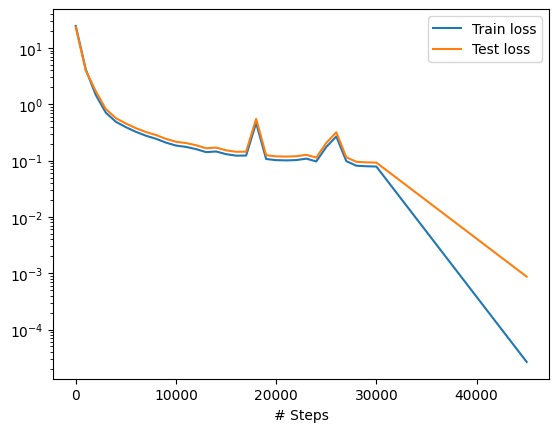

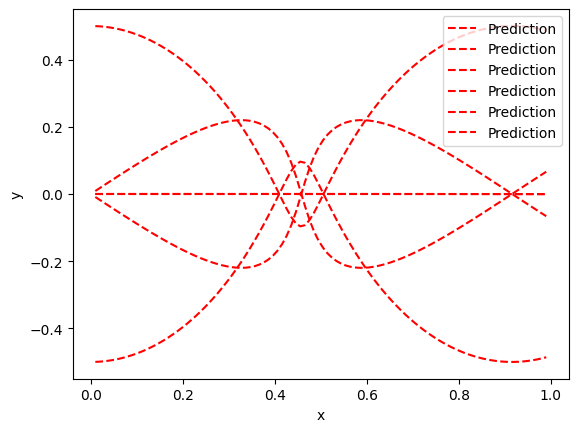

In [10]:
dde.config.set_default_float("float64")
np.random.seed(137)
tf.random.set_seed(137)

# Constants
G = 1.0
m = [1.0, 1.0, 1.0]
endTime = 1

num_domain = 64
num_boundary = 12
num_test = 100

layer_size = [1] + [128]*3 + [6]  # 6 outputs for positions only
activation = "tanh"
initializer = "Glorot uniform"
loss_weights = [1]*6
iterations = 30000
learning_rate = 1e-4
eps = 1e-9

# --------------------------------------------------
# Initial conditions
# --------------------------------------------------
# positions
x1_0, y1_0 = -0.5, 0.0
x2_0, y2_0 =  0.5, 0.0
x3_0, y3_0 =  0.0, 0.0

# velocities
vx1_0, vy1_0 = 0.0, 0.9
vx2_0, vy2_0 = 0.0, -0.9
vx3_0, vy3_0 = 0.0, 0.0

y0 = np.array([x1_0, y1_0, x2_0, y2_0,x3_0, y3_0], dtype=np.float64)
v0 = np.array([vx1_0, vy1_0, vx2_0, vy2_0,vx3_0, vy3_0], dtype=np.float64)

y0_tf = tf.constant(y0)
v0_tf = tf.constant(v0)


# ============================================================
# Residual for second-order ODEs
# ============================================================
def three_body_ode_second(t, y):
    # r: [batch_size, 6] -> x1,y1,x2,y2,x3,y3
    x1, y1, x2, y2, x3, y3 = [y[:, i:i+1] for i in range(6)]

    # pairwise distances
    r12 = tf.sqrt((x1 - x2)**2 + (y1 - y2)**2 )
    r13 = tf.sqrt((x1 - x3)**2 + (y1 - y3)**2 )
    r23 = tf.sqrt((x2 - x3)**2 + (y2 - y3)**2 )

    r12_3 = (r12+eps)**3
    r13_3 = (r13+eps)**3
    r23_3 = (r23+eps)**3

    # accelerations
    ax1 = G*( m[1]*(x2 - x1)/r12_3 + m[2]*(x3 - x1)/r13_3 )
    ay1 = G*( m[1]*(y2 - y1)/r12_3 + m[2]*(y3 - y1)/r13_3 )
    ax2 = G*( m[0]*(x1 - x2)/r12_3 + m[2]*(x3 - x2)/r23_3 )
    ay2 = G*( m[0]*(y1 - y2)/r12_3 + m[2]*(y3 - y2)/r23_3 )
    ax3 = G*( m[0]*(x1 - x3)/r13_3 + m[1]*(x2 - x3)/r23_3 )
    ay3 = G*( m[0]*(y1 - y3)/r13_3 + m[1]*(y2 - y3)/r23_3 )

    # second derivatives
    x1_tt = dde.grad.hessian(y, t, component=0, i=0, j=0)
    y1_tt = dde.grad.hessian(y, t, component=1, i=0, j=0)
    x2_tt = dde.grad.hessian(y, t, component=2, i=0, j=0)
    y2_tt = dde.grad.hessian(y, t, component=3, i=0, j=0)
    x3_tt = dde.grad.hessian(y, t, component=4, i=0, j=0)
    y3_tt = dde.grad.hessian(y, t, component=5, i=0, j=0)

    return [
        x1_tt - ax1,
        y1_tt - ay1,
        x2_tt - ax2,
        y2_tt - ay2,
        x3_tt - ax3,
        y3_tt - ay3
    ]

# --------------------------------------------------
# Geometry
# --------------------------------------------------
geom = dde.geometry.TimeDomain(0, endTime)


data = dde.data.PDE(
    geom,
    three_body_ode_second,
    [],
    num_domain=num_domain,
    num_boundary=num_boundary,
    num_test=num_test
)

# ============================================================
# Network and hard constraints
# ============================================================
net = dde.nn.FNN(layer_size, activation, initializer)

# --------------------------------------------------
# HARD CONSTRAINTS (position + velocity)
# --------------------------------------------------
def output_transform(t, y):
    """
    Enforces:
    y(0) = y0
    y'(0) = v0
    """
    return y0_tf + v0_tf * t + (t**2) * y

net.apply_output_transform(output_transform)

model = dde.Model(data, net)


#model.compile(
#    optimizer=tf.keras.optimizers.AdamW(1e-4, weight_decay=1e-5,loss_weights=loss_weights),
#    loss="MSE",
#)
model.compile("adam", lr=learning_rate, loss_weights=loss_weights, loss="MSE")
losshistory, train_state = model.train(iterations=iterations)

model.compile("L-BFGS")  # no learning rate needed
losshistory, train_state = model.train()

dde.saveplot(losshistory, train_state, issave=True, isplot=True)

# ============================================================
# PINN Predictions
# ============================================================
t_test = np.linspace(0, endTime, 5000)[:, None]
y_pred = model.predict(t_test)

x1, y1 = y_pred[:, 0], y_pred[:, 1]
x2, y2 = y_pred[:, 2], y_pred[:, 3]
x3, y3 = y_pred[:, 4], y_pred[:, 5]

# ============================================================
# Numerical Solution via SciPy
# ============================================================
def three_body_numeric(t, y, G=1.0, m=(1.0, 1.0, 1.0)):
    x1, y1, vx1, vy1, x2, y2, vx2, vy2, x3, y3, vx3, vy3 = y

    r12 = np.sqrt((x1 - x2)**2 + (y1 - y2)**2 + eps)
    r13 = np.sqrt((x1 - x3)**2 + (y1 - y3)**2 + eps)
    r23 = np.sqrt((x2 - x3)**2 + (y2 - y3)**2 + eps)

    ax1 = G * (m[1]*(x2 - x1)/r12**3 + m[2]*(x3 - x1)/r13**3)
    ay1 = G * (m[1]*(y2 - y1)/r12**3 + m[2]*(y3 - y1)/r13**3)
    ax2 = G * (m[0]*(x1 - x2)/r12**3 + m[2]*(x3 - x2)/r23**3)
    ay2 = G * (m[0]*(y1 - y2)/r12**3 + m[2]*(y3 - y2)/r23**3)
    ax3 = G * (m[0]*(x1 - x3)/r13**3 + m[1]*(x2 - x3)/r23**3)
    ay3 = G * (m[0]*(y1 - y3)/r13**3 + m[1]*(y2 - y3)/r23**3)

    return [vx1, vy1, ax1, ay1,
            vx2, vy2, ax2, ay2,
            vx3, vy3, ax3, ay3]

t_span = (0, endTime)
t_eval = np.linspace(0, endTime, 5000)

y0_full = np.array([
    x1_0, y1_0, vx1_0, vy1_0,
    x2_0, y2_0, vx2_0, vy2_0,
    x3_0, y3_0, vx3_0, vy3_0
])

sol = solve_ivp(three_body_numeric, t_span, y0_full, t_eval=t_eval, rtol=1e-10, atol=1e-12)

x1_n, y1_n = sol.y[0], sol.y[1]
x2_n, y2_n = sol.y[4], sol.y[5]
x3_n, y3_n = sol.y[8], sol.y[9]


#Plots-Results

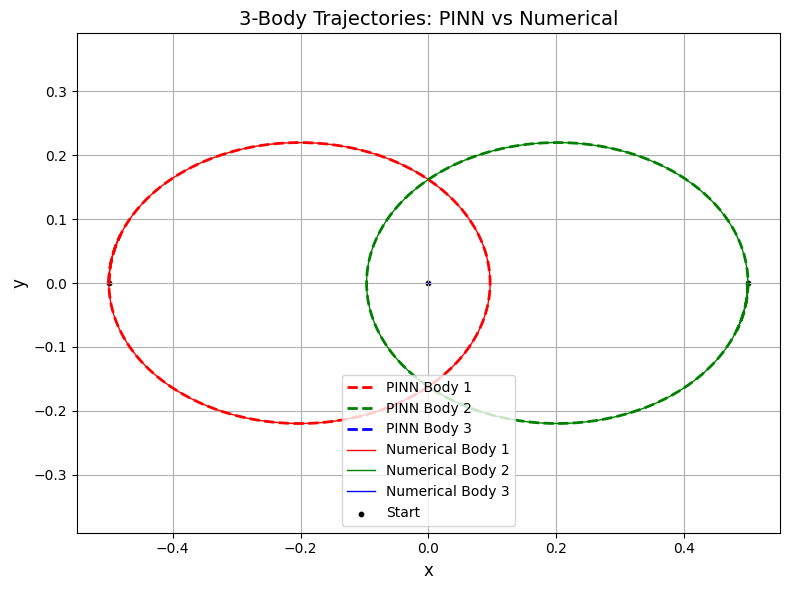


--- Relative L2 Errors (2D Position) ---
Body 1: 2.57e-04
Body 2: 5.26e-04

--- Absolute L2 Error (2D Position) ---
Body 3: 1.27e-02
(33, 6)


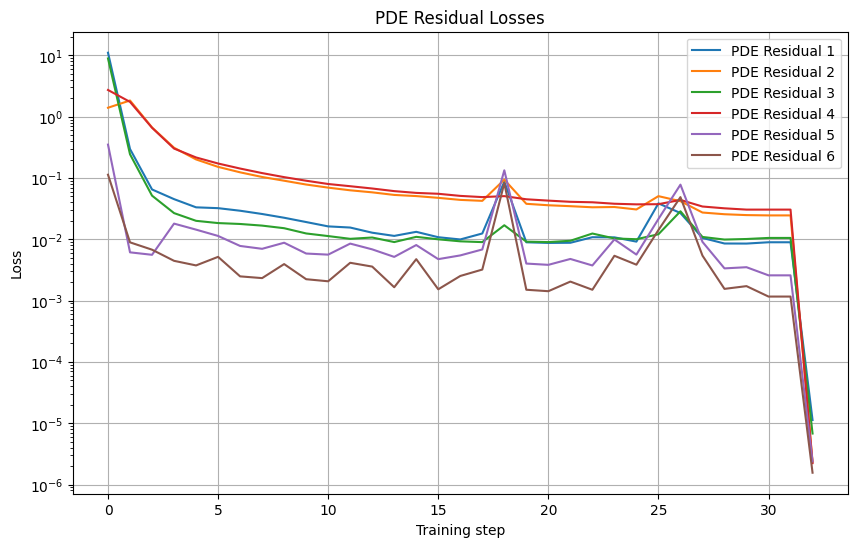

In [17]:
plt.figure(figsize=(8, 6))
plt.plot(x1, y1, 'r--', lw=2, label="PINN Body 1")
plt.plot(x2, y2, 'g--', lw=2, label="PINN Body 2")
plt.plot(x3, y3, 'b--', lw=2, label="PINN Body 3")

plt.plot(x1_n, y1_n, 'r-', lw=1, label="Numerical Body 1")
plt.plot(x2_n, y2_n, 'g-', lw=1, label="Numerical Body 2")
plt.plot(x3_n, y3_n, 'b-', lw=1, label="Numerical Body 3")

plt.scatter([x1[0], x2[0], x3[0]],
            [y1[0], y2[0], y3[0]],
            color='k', marker='o', s=10, label='Start')

plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("3-Body Trajectories: PINN vs Numerical", fontsize=14)
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()

# ============================================================
# Optional: Compute relative L2 errors
# ============================================================


# Interpolate numerical solution onto PINN time grid
interp_x1 = interp1d(t_eval, x1_n, kind="cubic")
interp_y1 = interp1d(t_eval, y1_n, kind="cubic")

interp_x2 = interp1d(t_eval, x2_n, kind="cubic")
interp_y2 = interp1d(t_eval, y2_n, kind="cubic")

interp_x3 = interp1d(t_eval, x3_n, kind="cubic")
interp_y3 = interp1d(t_eval, y3_n, kind="cubic")

# Numerical reference values at PINN times
x1_ref = interp_x1(t_test[:, 0])
y1_ref = interp_y1(t_test[:, 0])

x2_ref = interp_x2(t_test[:, 0])
y2_ref = interp_y2(t_test[:, 0])

x3_ref = interp_x3(t_test[:, 0])
y3_ref = interp_y3(t_test[:, 0])

# Stack positions into vectors [x(t), y(t)]
pinn_body1 = np.vstack((x1, y1)).T
ref_body1  = np.vstack((x1_ref, y1_ref)).T

pinn_body2 = np.vstack((x2, y2)).T
ref_body2  = np.vstack((x2_ref, y2_ref)).T

pinn_body3 = np.vstack((x3, y3)).T
ref_body3  = np.vstack((x3_ref, y3_ref)).T

# Relative L2 error over full 2D trajectory
err_body1 = norm(pinn_body1 - ref_body1) / norm(ref_body1)
err_body2 = norm(pinn_body2 - ref_body2) / norm(ref_body2)
err_body3 = norm(pinn_body3 - ref_body3)    # absolute error since body 3 not moving

print("\n--- Relative L2 Errors (2D Position) ---")
print(f"Body 1: {err_body1:.2e}")
print(f"Body 2: {err_body2:.2e}")

print("\n--- Absolute L2 Error (2D Position) ---")
print(f"Body 3: {err_body3:.2e}")



#============================ history losses per pfe res =================================
losses = np.array(losshistory.loss_train)
print(losses.shape)

#dde.utils.plot_loss_history(losshistory)


pde_losses = losses[:, 1:13]

plt.figure(figsize=(10, 6))

for i in range(6):
    plt.semilogy(losses[:, i], label=f"PDE Residual {i+1}")

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("PDE Residual Losses")
plt.legend()
plt.grid(True)
plt.show()


#Extrapolate for 1/2 of  Period

======================= Extrapolating for  1/2 of period ===============================


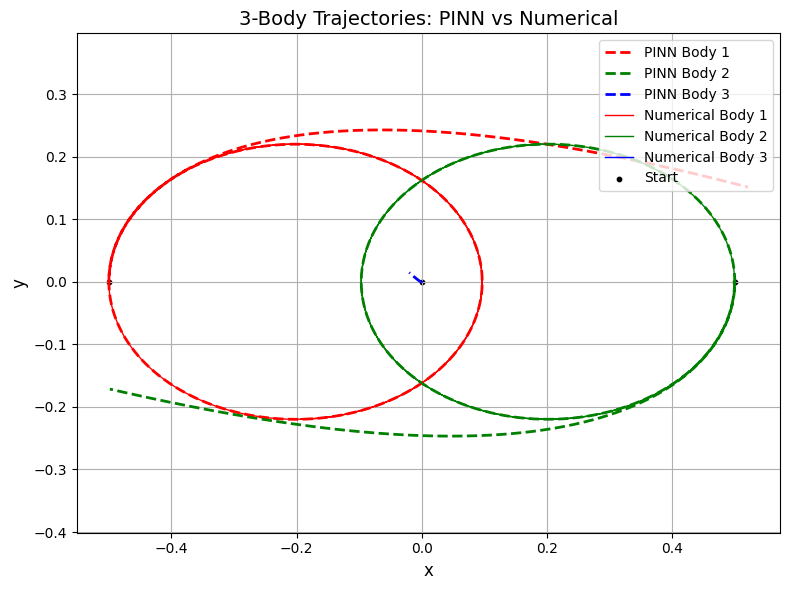


--- Relative L2 Errors (2D Position) ---
Body 1: 4.27e-01
Body 2: 4.26e-01

--- Absolute L2 Error (2D Position) ---
Body 3: 4.05e-01


In [18]:
print("===================================================================================")
print("======================= Extrapolating for  1/2 of period ===============================")
print("===================================================================================")

endTime=1+1/2

# ============================================================
# PINN Predictions
# ============================================================
t_test = np.linspace(0, endTime, 5000)[:, None]
y_pred = model.predict(t_test)

x1, y1 = y_pred[:, 0], y_pred[:, 1]
x2, y2 = y_pred[:, 2], y_pred[:, 3]
x3, y3 = y_pred[:, 4], y_pred[:, 5]

# ============================================================
# Numerical Solution via SciPy
# ============================================================
def three_body_numeric(t, y, G=1.0, m=(1.0, 1.0, 1.0)):
    x1, y1, vx1, vy1, x2, y2, vx2, vy2, x3, y3, vx3, vy3 = y

    r12 = np.sqrt((x1 - x2)**2 + (y1 - y2)**2 + eps)
    r13 = np.sqrt((x1 - x3)**2 + (y1 - y3)**2 + eps)
    r23 = np.sqrt((x2 - x3)**2 + (y2 - y3)**2 + eps)

    ax1 = G * (m[1]*(x2 - x1)/r12**3 + m[2]*(x3 - x1)/r13**3)
    ay1 = G * (m[1]*(y2 - y1)/r12**3 + m[2]*(y3 - y1)/r13**3)
    ax2 = G * (m[0]*(x1 - x2)/r12**3 + m[2]*(x3 - x2)/r23**3)
    ay2 = G * (m[0]*(y1 - y2)/r12**3 + m[2]*(y3 - y2)/r23**3)
    ax3 = G * (m[0]*(x1 - x3)/r13**3 + m[1]*(x2 - x3)/r23**3)
    ay3 = G * (m[0]*(y1 - y3)/r13**3 + m[1]*(y2 - y3)/r23**3)

    return [vx1, vy1, ax1, ay1,
            vx2, vy2, ax2, ay2,
            vx3, vy3, ax3, ay3]

t_span = (0, endTime)
t_eval = np.linspace(0, endTime, 5000)

y0_full = np.array([
    x1_0, y1_0, vx1_0, vy1_0,
    x2_0, y2_0, vx2_0, vy2_0,
    x3_0, y3_0, vx3_0, vy3_0
])

sol = solve_ivp(three_body_numeric, t_span, y0_full, t_eval=t_eval, rtol=1e-10, atol=1e-12)

x1_n, y1_n = sol.y[0], sol.y[1]
x2_n, y2_n = sol.y[4], sol.y[5]
x3_n, y3_n = sol.y[8], sol.y[9]

# ============================================================
# Compare and Plot Results
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(x1, y1, 'r--', lw=2, label="PINN Body 1")
plt.plot(x2, y2, 'g--', lw=2, label="PINN Body 2")
plt.plot(x3, y3, 'b--', lw=2, label="PINN Body 3")

plt.plot(x1_n, y1_n, 'r-', lw=1, label="Numerical Body 1")
plt.plot(x2_n, y2_n, 'g-', lw=1, label="Numerical Body 2")
plt.plot(x3_n, y3_n, 'b-', lw=1, label="Numerical Body 3")

plt.scatter([x1[0], x2[0], x3[0]],
            [y1[0], y2[0], y3[0]],
            color='k', marker='o', s=10, label='Start')

plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("3-Body Trajectories: PINN vs Numerical", fontsize=14)
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()

# ============================================================
# Optional: Compute relative L2 errors
# ============================================================


# Interpolate numerical solution onto PINN time grid
interp_x1 = interp1d(t_eval, x1_n, kind="cubic")
interp_y1 = interp1d(t_eval, y1_n, kind="cubic")

interp_x2 = interp1d(t_eval, x2_n, kind="cubic")
interp_y2 = interp1d(t_eval, y2_n, kind="cubic")

interp_x3 = interp1d(t_eval, x3_n, kind="cubic")
interp_y3 = interp1d(t_eval, y3_n, kind="cubic")

# Numerical reference values at PINN times
x1_ref = interp_x1(t_test[:, 0])
y1_ref = interp_y1(t_test[:, 0])

x2_ref = interp_x2(t_test[:, 0])
y2_ref = interp_y2(t_test[:, 0])

x3_ref = interp_x3(t_test[:, 0])
y3_ref = interp_y3(t_test[:, 0])

# Stack positions into vectors [x(t), y(t)]
pinn_body1 = np.vstack((x1, y1)).T
ref_body1  = np.vstack((x1_ref, y1_ref)).T

pinn_body2 = np.vstack((x2, y2)).T
ref_body2  = np.vstack((x2_ref, y2_ref)).T

pinn_body3 = np.vstack((x3, y3)).T
ref_body3  = np.vstack((x3_ref, y3_ref)).T

# Relative L2 error over full 2D trajectory
err_body1 = norm(pinn_body1 - ref_body1) / norm(ref_body1)
err_body2 = norm(pinn_body2 - ref_body2) / norm(ref_body2)
err_body3 = norm(pinn_body3 - ref_body3)    # absolute error since body 3 not moving

print("\n--- Relative L2 Errors (2D Position) ---")
print(f"Body 1: {err_body1:.2e}")
print(f"Body 2: {err_body2:.2e}")

print("\n--- Absolute L2 Error (2D Position) ---")
print(f"Body 3: {err_body3:.2e}")


